# Session 1: Python and NumPy

---
# Part 2: NumPy

## 2.1 Why NumPy?

Python lists are flexible but slow for numbers. NumPy arrays store numbers in one block of memory and run operations in compiled code. That's called **vectorization**: operate on the whole array at once instead of looping.

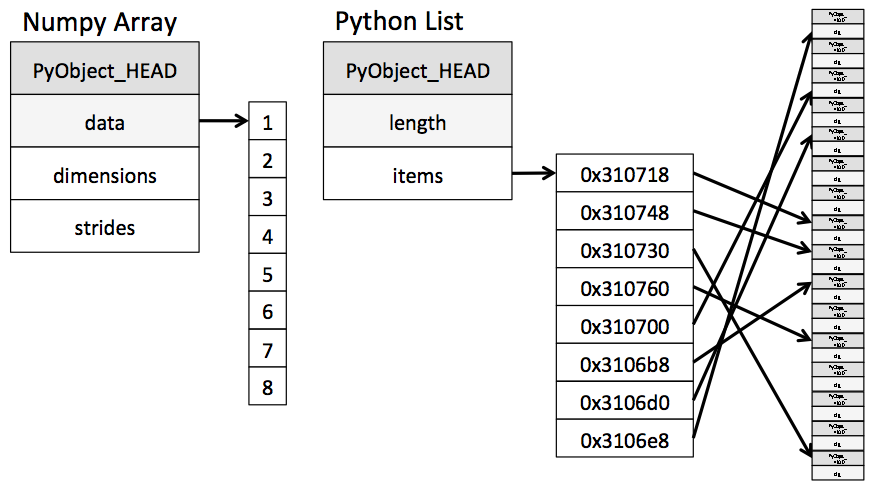

*from Python Data Science Handbook*

In [1]:
import numpy as np
values = list(range(1_000_000))
values_array = np.arange(1_000_000)

# using timeit

## 2.2 Creating arrays

In [7]:
# from a list, zeros, ones, arange, linspace


## 2.3 Shape, dimensions and type

- `shape`: the size along each axis, as a tuple
- `ndim`: the number of axes
- `dtype`: the type of every element (an array has one type)

In [8]:
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])


`reshape` changes the shape without changing the data. The total number of elements must stay the same.

> **Shape habit.** When something breaks, print `.shape` first. Most beginner ML bugs are shape mismatches: a `(100,)` vector where a `(100, 1)` column was expected, or features and samples swapped.

### ✏️ Create `grid`: the numbers 0 to 19 arranged in 4 rows and 5 columns.

## 2.4 Element-wise operations and broadcasting

Arithmetic on arrays works **element by element**. No loop needed.

In [18]:
# sum, multiplication, power, other functions
a = np.array([1, 2, 3])
b = np.array([10, 20, 30])


**Broadcasting**: when shapes differ, NumPy stretches the smaller array to match, if the shapes are compatible. Compatible means that, comparing shapes from the right, each pair of sizes is equal or one of them is 1.

Our running example is a small gene-expression table: 6 samples (rows) × 4 genes (columns), with a label per sample (0 = healthy, 1 = tumor). This `X` / `y` layout is exactly what every ML model expects.

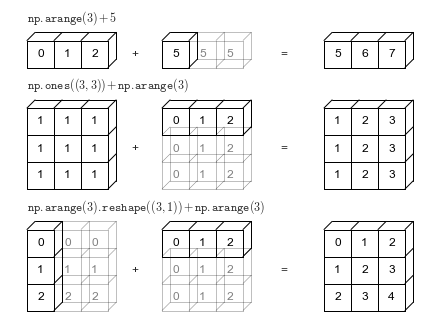

*from https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html*

In [2]:
gene_names = np.array(["TP53", "BRCA1", "MYC", "GAPDH"])
X = np.array([
    [5.1, 2.0, 7.9, 10.2],
    [3.2, 1.1, 12.4, 10.0],
    [5.6, 2.3, 8.1, 9.8],
    [2.9, 0.8, 13.0, 10.4],
    [3.4, 1.0, 11.7, 10.1],
    [5.3, 2.2, 7.5, 9.9],
])
y = np.array([0, 1, 0, 1, 1, 0])
print("X:", X.shape, " y:", y.shape)



X: (6, 4)  y: (6,)


In [3]:
# broadcasting in multiplication and addition
gene_offsets = np.array([1, 0, -1, 0])


## 2.5 Indexing

### Slicing in 2D

`X[row, column]`. A `:` means "everything along this axis".

### Boolean masks

A comparison gives an array of `True`/`False`. Using it as an index keeps only the `True` positions.

In [ ]:
# only tumor samples

In [ ]:
# MYC values above 10

### Fancy indexing (with integer arrays)

Index with a list or array of positions to pick exactly those elements, in that order.

In [ ]:
# MYC, then TP53

In [ ]:
# samples 0, 5 and 3, in that order

**Shuffling** uses fancy indexing. Shuffle `X` and `y` with the **same** permutation so each sample keeps its label. A train/test split works like this underneath.

In [4]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(y))

X_shuffled = X[idx]
y_shuffled = y[idx]
print(y_shuffled)


[1 0 0 1 1 0]


## 2.6 `axis`

Reductions like `mean`, `sum` and `max` can work along one axis.

- `axis=0` goes **down the rows** and gives one value **per column** (per gene).
- `axis=1` goes **across the columns** and gives one value **per row** (per sample).


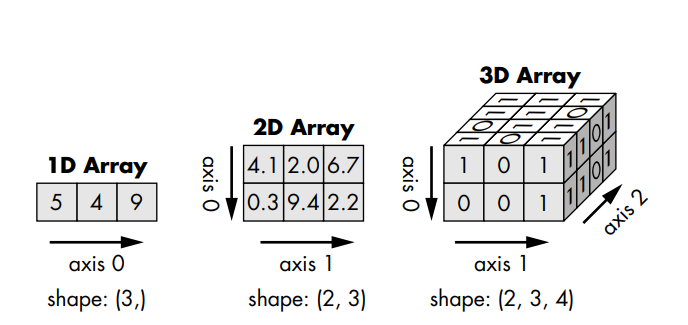

*from https://medium.com/data-science/introducing-numpy-part-2-indexing-arrays-5b381b90d1d0*

In [10]:
# Overall, per gene, and per sample mean


In [9]:
# Axis + broadcasting = centering every gene, the first step of standardization


### ✏️ Using a Boolean mask and `axis`, compute `tumor_means`: the mean expression **of each gene** across **tumor samples only**. Which gene changes most between healthy and tumor?

## 2.7 Random numbers

Use a **generator** with a **seed**. The same seed gives the same "random" numbers every time, so your results are reproducible.

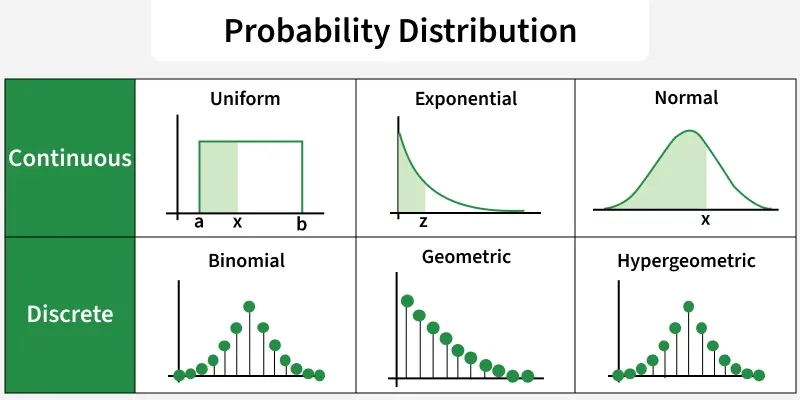

*from https://www.geeksforgeeks.org/maths/introduction-to-probability-distribution/*


In [18]:
rng = np.random.default_rng(seed=42)

print(rng.random(5)) # uniform on [0, 1)
print(rng.integers(1, 7, size=10)) # discrete uniform from 1 to 6 (dice)
print(rng.binomial(n=1, p=0.3, size=10)) # Bernoulli: 1 with probability 0.3
print(rng.choice(["hip", "hop"], size=5)) # pick from a list
print(rng.normal(loc=0, scale=1, size=3)) # normal distribution

[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
[4 6 5 5 5 5 4 1 6 3]
[0 1 0 1 0 0 0 0 1 0]
['hip' 'hop' 'hop' 'hip' 'hip']
[-0.15452948 -0.42832782 -0.35213355]


You'll also see the older style `np.random.rand(...)`, `np.random.seed(...)` in tutorials and on the exercise sheet. It still works. For new code, prefer `default_rng`.

### ✏️ Exercise 3

A common trick to generate 100 samples of a binary variable with probability 0.7 for `True` (and 0.3 for `False`) is:

```python
np.random.rand(100) <= 0.7
```

**Explain why this trick produces the desired result.** 